The ``aaanalysis.pipe`` (``ap``) module provides high-level **golden pipelines** — stateless, one-call wrappers over the AAanalysis primitives. ``ap.explain_features`` is the *pro* **explanation** pipeline: given an existing ``df_feat`` and the sequences, it rebuilds the feature matrix, fits a :class:`ShapModel`, attaches the per-sample SHAP feature impact to ``df_feat``, and draws the SHAP-coloured feature map. It returns the triple ``(df_feat_shap, ax, None)`` (explanation does no evaluation). It requires ``aaanalysis[pro]`` (SHAP).

In [1]:
import matplotlib.pyplot as plt
import aaanalysis as aa
import aaanalysis.pipe as ap

aa.options["verbose"] = False
aa.plot_settings()

# Sequences (df_seq) + labels and a discovered feature set (df_feat, e.g. from ap.find_features)
df_seq = aa.load_dataset(name="DOM_GSEC", n=20)
labels = df_seq["label"].to_list()
df_feat = aa.load_features().head(25)

aa.display_df(df_feat, n_rows=10, show_shape=True)

DataFrame shape: (25, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...3,4)-HUTJ700102",Energy,Entropy,Entropy,"Absolute entrop...Hutchens, 1970)",0.229000,0.098224,0.098224,0.106865,0.124608,0.000000,0.000001,"31,32,33,34,35",3.111200,3.109955
5,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
6,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
7,"TMD_C_JMD_C-Seg...4,5)-FAUJ880109",Energy,Isoelectric point,Number hydrogen bond donors,"Number of hydro...e et al., 1988)",0.215000,0.146661,0.146661,0.174609,0.188034,0.000000,0.000004,"33,34,35,36",1.032400,1.510722
8,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
9,"TMD_C_JMD_C-Seg...,10)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.212000,0.141305,-0.141305,0.168603,0.217235,0.000000,0.000005,"33,34",1.747200,2.150664
10,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803


By default a **single** sample is explained: the ``label_target_class`` sample the models predict most confidently — the most representative correct prediction. The per-sample SHAP impact is added to ``df_feat`` as a ``feat_impact_'entry'`` column, and the feature map colours each feature by that signed impact. ``random_state`` makes the SHAP estimation and the sample selection reproducible; ``n_jobs`` parallelizes the feature-matrix build:

/Users/stephanbreimann/Programming/1Packages/wt-412-explain-meandif/aaanalysis/feature_engineering/_backend/cpp_run.py:164: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


impact columns: ['feat_impact_Q06481'] | evals: None


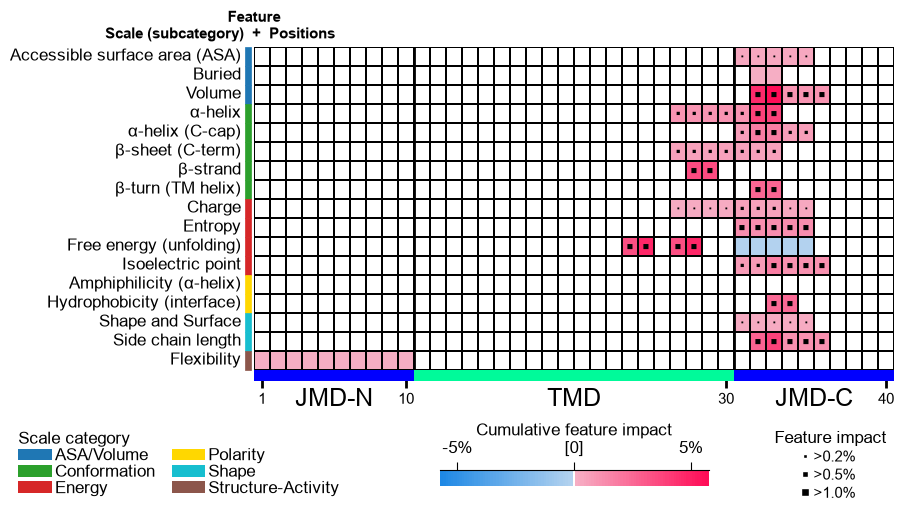

In [2]:
df_shap, ax, evals = ap.explain_features(df_feat, df_seq, labels,
                                          random_state=42, n_jobs=1)

impact_cols = [c for c in df_shap.columns if c.startswith("feat_impact_")]
print("impact columns:", impact_cols, "| evals:", evals)
plt.tight_layout()
plt.show()

Pass ``samples`` to explain chosen sample(s) instead of auto-selecting — an ``entry`` name, a row position, or a list of them. ``label_target_class`` sets the class SHAP targets, ``list_model_classes`` overrides the prediction models, and ``plot=False`` skips the figure (``ax`` is then ``None``). Here we explain two named proteins with an explicit model list:

In [3]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

entries = df_seq["entry"].iloc[:2].to_list()
df_shap, ax, _ = ap.explain_features(df_feat, df_seq, labels,
                                      samples=entries,
                                      label_target_class=1,
                                      list_model_classes=[RandomForestClassifier, ExtraTreesClassifier],
                                      plot=False, random_state=42, n_jobs=1, verbose=False)

cols = ["feature"] + [c for c in df_shap.columns if c.startswith("feat_impact_")]
aa.display_df(df_shap[cols], n_rows=10, show_shape=True)

DataFrame shape: (25, 3)


,feature,feat_impact_Q14802,feat_impact_Q86UE4
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",-0.110000,-2.300000
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",-0.520000,-2.370000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",-7.850000,-4.720000
4,"TMD_C_JMD_C-Seg...3,4)-HUTJ700102",-5.370000,-4.380000
5,"TMD_C_JMD_C-Seg...6,9)-RADA880106",-9.310000,-5.250000
6,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",0.090000,-2.490000
7,"TMD_C_JMD_C-Seg...4,5)-FAUJ880109",-6.880000,-7.960000
8,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",-1.560000,-0.650000
9,"TMD_C_JMD_C-Seg...,10)-WILM950103",-7.300000,-6.520000
10,"TMD_C_JMD_C-Seg...6,9)-AURR980110",-11.270000,-0.040000


Set ``add_sample_mean_dif=True`` to also enrich ``df_feat`` with per-sample **mean-difference** columns ``mean_dif_'name'`` (each sample's feature value minus the ``label_ref`` group average) alongside the SHAP ``feat_impact_'name'`` columns. This is the per-sample contrast a sample-level CPP-SHAP map or ranking is coloured by, kept separate from plotting; ``label_ref`` chooses the reference group:

In [4]:
df_shap, ax, _ = ap.explain_features(df_feat, df_seq, labels,
                                     samples=df_seq["entry"].iloc[0],
                                     add_sample_mean_dif=True, label_ref=0,
                                     plot=False, random_state=42, n_jobs=1)

name = df_seq["entry"].iloc[0]
cols = ["feature", f"feat_impact_{name}", f"mean_dif_{name}"]
aa.display_df(df_shap[cols], n_rows=10, show_shape=True)

DataFrame shape: (25, 3)


,feature,feat_impact_Q14802,mean_dif_Q14802
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",-0.110000,0.085000
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",-0.520000,0.078780
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",-7.850000,0.092233
4,"TMD_C_JMD_C-Seg...3,4)-HUTJ700102",-5.370000,0.045490
5,"TMD_C_JMD_C-Seg...6,9)-RADA880106",-9.310000,0.073717
6,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",0.090000,0.060716
7,"TMD_C_JMD_C-Seg...4,5)-FAUJ880109",-6.880000,-0.040625
8,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",-1.560000,0.023330
9,"TMD_C_JMD_C-Seg...,10)-WILM950103",-7.300000,0.183475
10,"TMD_C_JMD_C-Seg...6,9)-AURR980110",-11.270000,-0.005536


With ``plot=True`` the SHAP-coloured feature map is drawn for the first requested sample; ``name_test`` and ``name_ref`` label the two groups. The returned ``ax`` is the feature-map ``Axes``:

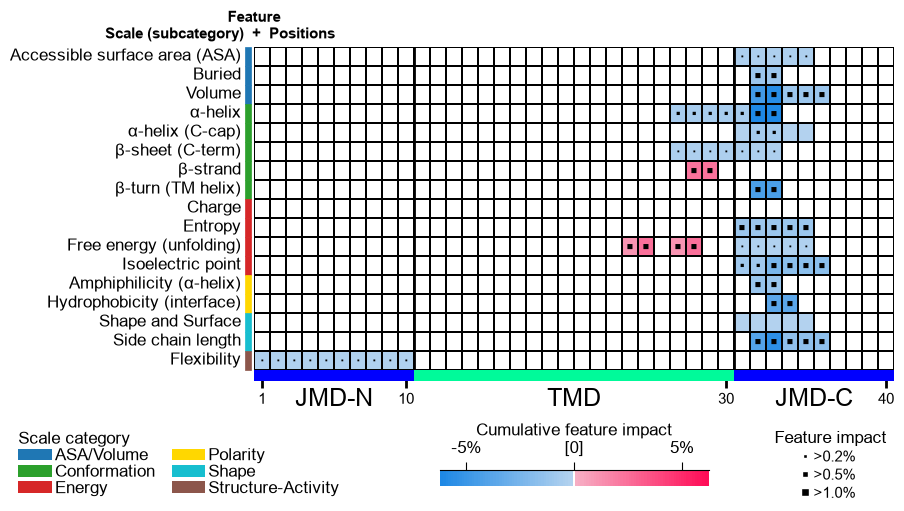

In [5]:
df_shap, ax, _ = ap.explain_features(df_feat, df_seq, labels,
                                      samples=df_seq["entry"].iloc[0],
                                      name_test="SUBSTRATE", name_ref="NON-SUB",
                                      plot=True, random_state=42, n_jobs=1)

plt.tight_layout()
plt.show()